In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])
df["Delivery_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Delivery_Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


## Executive Summary — Key Metrics

In [ ]:
# Calculate key business performance metrics
total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_products = df["Product_ID"].nunique()
avg_delivery = df["Delivery_Days"].mean()

# Display the executive summary
print("="*40)
print("EXECUTIVE SUMMARY")
print("="*40)
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Unique Products: {total_products:,}")
print(f"Average Delivery Time: {avg_delivery:.1f} days")
print("="*40)

EXECUTIVE SUMMARY
Total Sales: $2,261,536.78
Total Orders: 4,922
Unique Customers: 793
Unique Products: 1,861
Average Delivery Time: 4.0 days


## Combined Dashboard

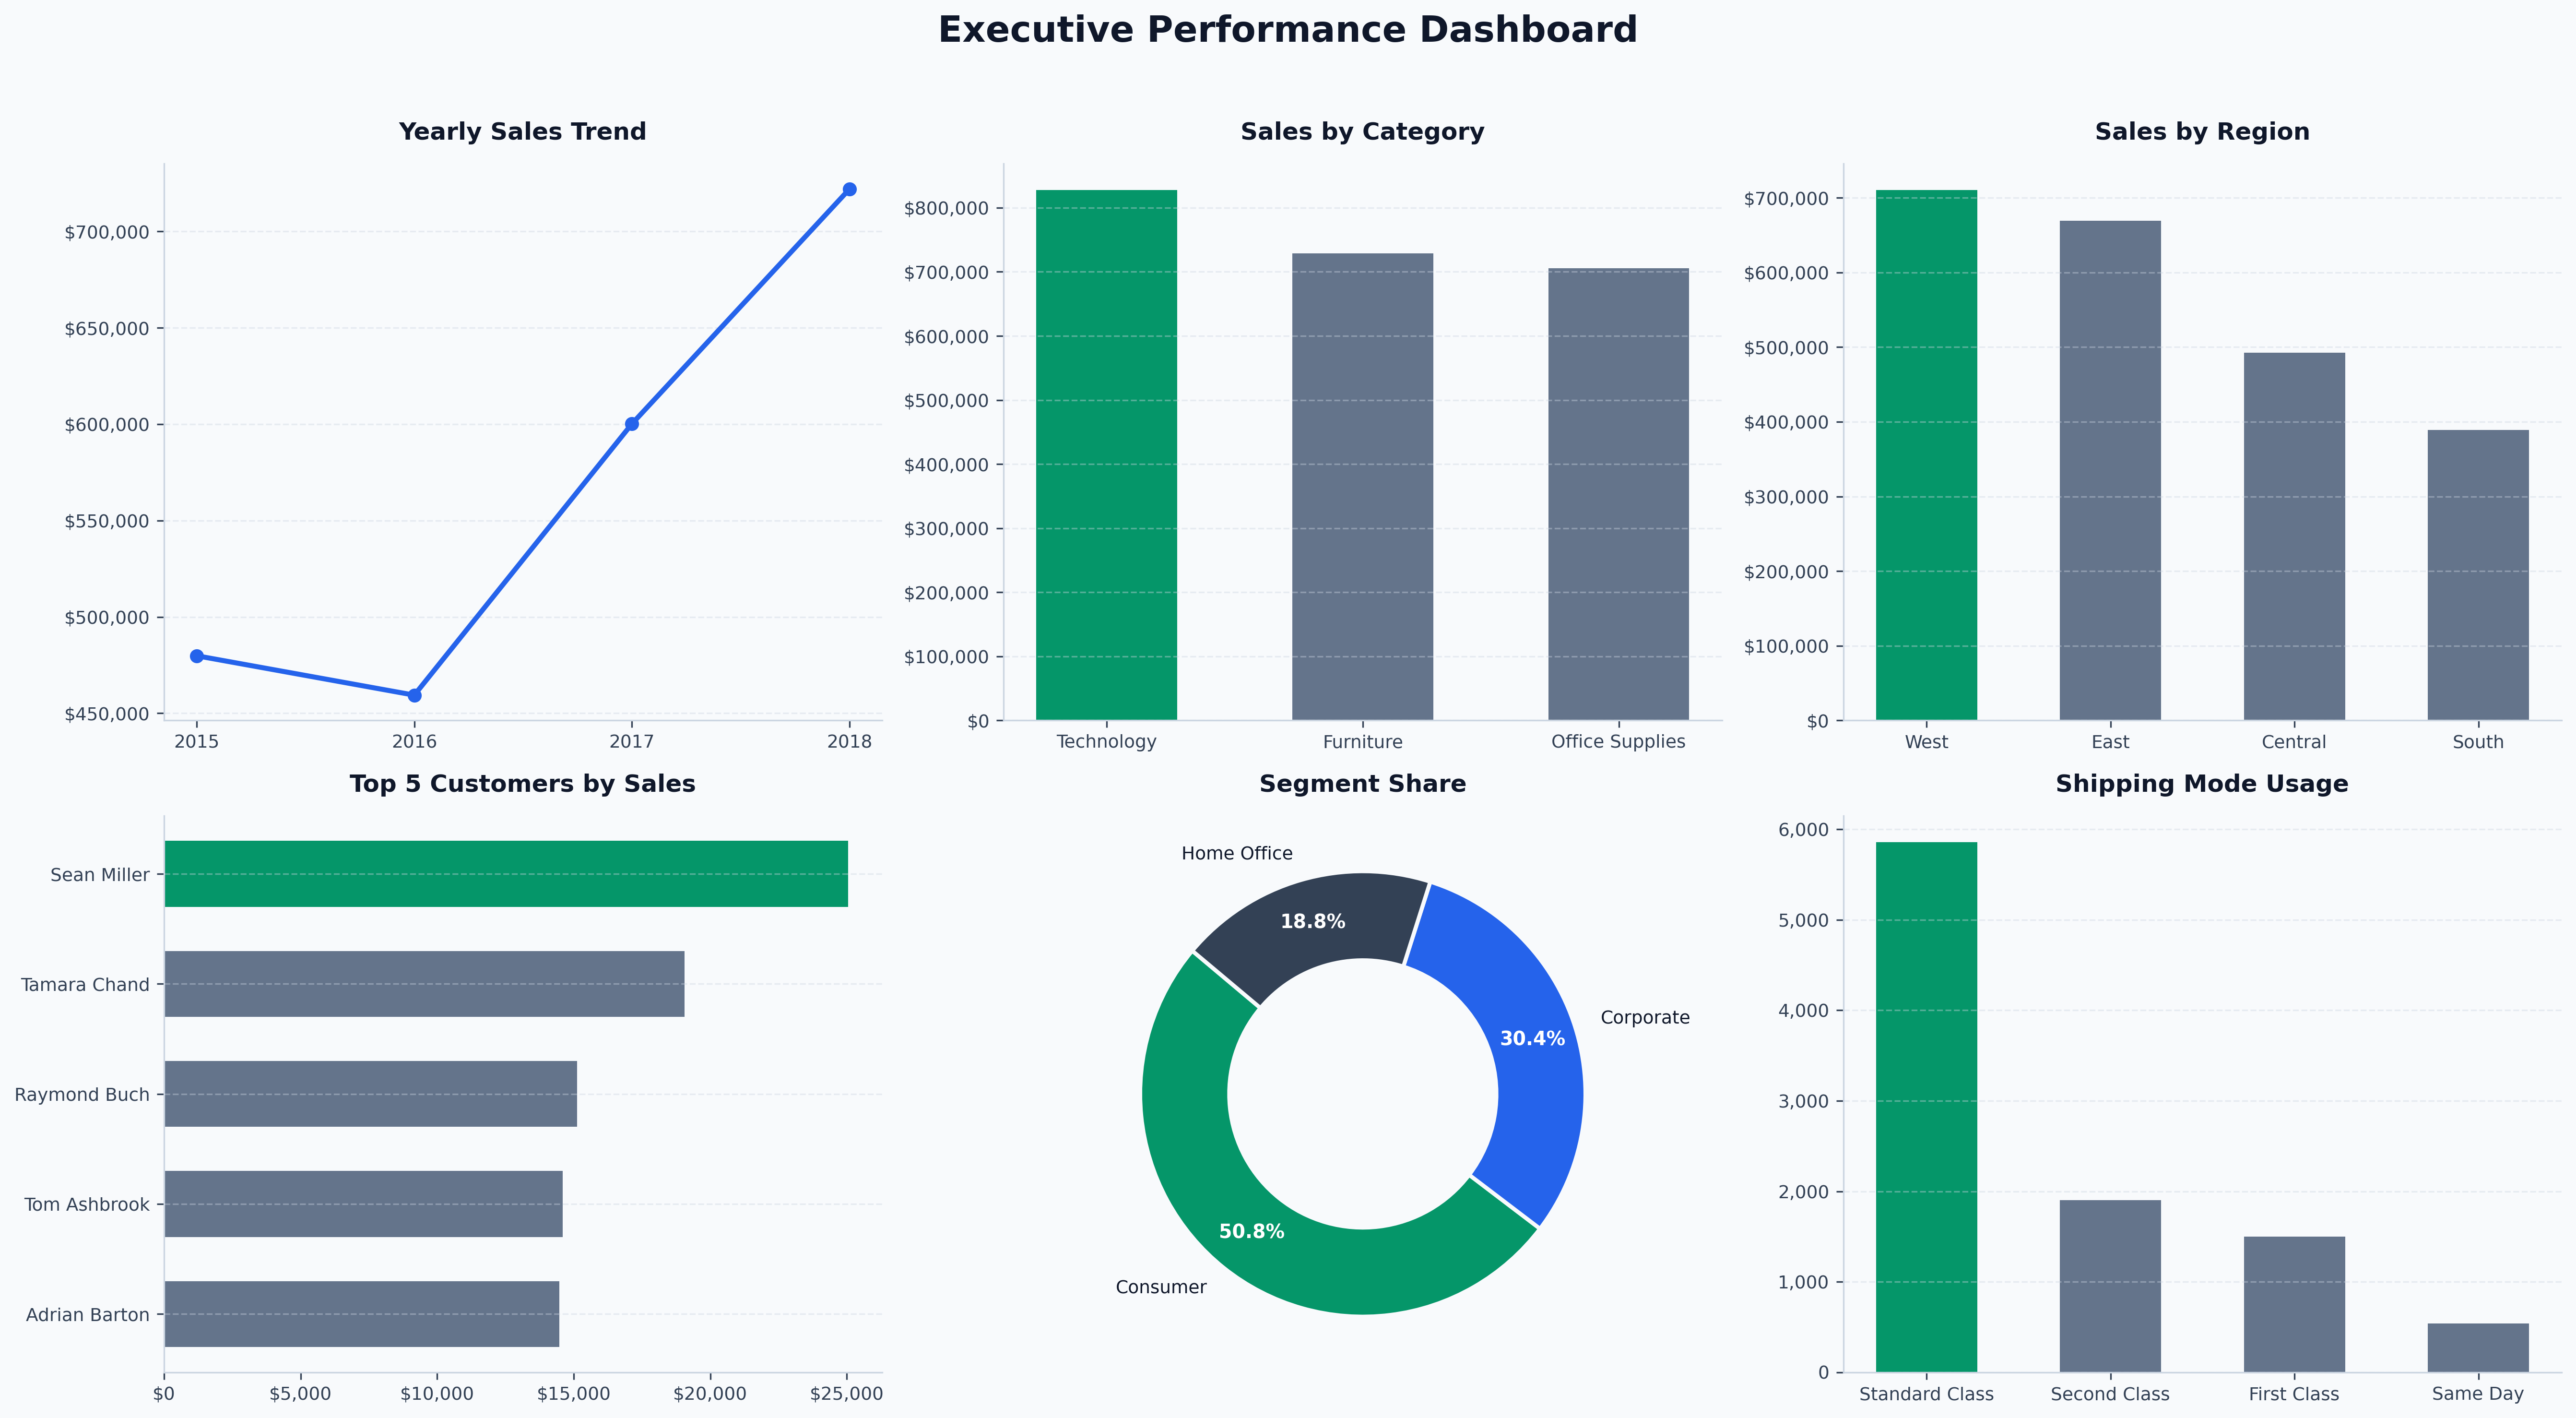

In [6]:
import matplotlib.ticker as ticker

# Create a 2x3 layout to display six key business insights in one dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
fig.patch.set_facecolor("#F8FAFC")

# Format large sales values as currency with commas and no decimal places
currency_fmt = ticker.StrMethodFormatter('${x:,.0f}')

# --- Subplot 1: Yearly Sales Trend (Line Plot) ---

# Aggregate total sales for each year
yearly_sales = df.groupby(df["Order_Date"].dt.year)["Sales"].sum()

# Set the subplot background and plot the yearly sales trend
axes[0, 0].set_facecolor("#F8FAFC")
axes[0, 0].plot(yearly_sales.index, yearly_sales.values, marker="o", linewidth=2.5, color="#2563EB", markersize=6)

# Add title and format the Y-axis as currency
axes[0, 0].set_title("Yearly Sales Trend", fontsize=12, fontweight="bold", color="#0F172A", pad=12)
axes[0, 0].yaxis.set_major_formatter(currency_fmt)

# Display years as whole numbers instead of decimal values
axes[0, 0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Subplot 2: Category Sales (Bar Plot) ---

# Calculate total sales for each category and sort from highest to lowest
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
axes[0, 1].set_facecolor("#F8FAFC")

# Highlight the highest-selling category with Emerald Green
colors = ["#059669" if i == 0 else "#64748B" for i in range(len(category_sales))]

# Plot total sales by category
axes[0, 1].bar(category_sales.index, category_sales.values, color=colors, width=0.55)
axes[0, 1].set_title("Sales by Category", fontsize=12, fontweight="bold", color="#0F172A", pad=12)
axes[0, 1].yaxis.set_major_formatter(currency_fmt)

# --- Subplot 3: Region Sales (Bar Plot) ---

# Calculate total sales for each region and sort from highest to lowest
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
axes[0, 2].set_facecolor("#F8FAFC")

# Highlight the highest-performing region with Emerald Green
colors = ["#059669" if i == 0 else "#64748B" for i in range(len(region_sales))]

# Plot total sales by region
axes[0, 2].bar(region_sales.index, region_sales.values, color=colors, width=0.55)
axes[0, 2].set_title("Sales by Region", fontsize=12, fontweight="bold", color="#0F172A", pad=12)
axes[0, 2].yaxis.set_major_formatter(currency_fmt)

# --- Subplot 4: Top 5 Customers (Horizontal Bar) ---

# Find the five customers who generated the highest total sales
top_customers = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False).head(5)
axes[1, 0].set_facecolor("#F8FAFC")

# Highlight the top customer with Emerald Green
colors = ["#059669" if i == 0 else "#64748B" for i in range(len(top_customers))]

# Plot the top five customers using a horizontal bar chart
axes[1, 0].barh(top_customers.index, top_customers.values, color=colors, height=0.6)
axes[1, 0].set_title("Top 5 Customers by Sales", fontsize=12, fontweight="bold", color="#0F172A", pad=12)
axes[1, 0].xaxis.set_major_formatter(currency_fmt)

# Reverse the order so the highest-selling customer appears at the top
axes[1, 0].invert_yaxis()

# --- Subplot 5: Segment Share (Donut Chart) ---

# Calculate total sales generated by each customer segment
segment_sales = df.groupby("Segment")["Sales"].sum()

# Define colors for the segment share chart
colors_pie = ["#059669", "#2563EB", "#334155"]

# Create a donut chart to show each segment's share of total sales
wedges, texts, autotexts = axes[1, 1].pie(
    segment_sales.values, 
    labels=segment_sales.index, 
    autopct="%1.1f%%", 

    # Position percentage values inside the donut ring
    pctdistance=0.8,

    # Position segment names slightly outside the donut ring
    labeldistance=1.12,

    colors=colors_pie,
    startangle=140,

    # Create the donut effect by adding width to the pie slices
    wedgeprops=dict(width=0.4, edgecolor="#F8FAFC", linewidth=2)
)

# Format percentage labels displayed inside the donut
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_weight("bold")
    autotext.set_fontsize(9.5)

# Format the segment names displayed outside the donut
for text in texts:
    text.set_color("#0F172A")
    text.set_fontsize(9)

axes[1, 1].set_title("Segment Share", fontsize=12, fontweight="bold", color="#0F172A", pad=12)

# --- Subplot 6: Ship Mode Usage (Bar Plot) ---

# Count how many orders used each shipping mode
shipmode_counts = df["Ship_Mode"].value_counts()
axes[1, 2].set_facecolor("#F8FAFC")

# Highlight the most frequently used shipping mode
colors = ["#059669" if i == 0 else "#64748B" for i in range(len(shipmode_counts))]

# Plot order volume for each shipping mode
axes[1, 2].bar(shipmode_counts.index, shipmode_counts.values, color=colors, width=0.55)
axes[1, 2].set_title("Shipping Mode Usage", fontsize=12, fontweight="bold", color="#0F172A", pad=12)

# Format order counts with commas for better readability
axes[1, 2].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# --- Apply Clean Spines & Grids to All Axes ---

# Apply consistent styling across all six dashboard charts
for ax in axes.flat:

    # Remove unnecessary top and right borders
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Style the remaining axes borders
    ax.spines["left"].set_color("#CBD5E1")
    ax.spines["bottom"].set_color("#CBD5E1")

    # Apply consistent tick styling
    ax.tick_params(colors="#334155", labelsize=9)

    # Add subtle horizontal grid lines for easier value comparison
    ax.grid(axis="y", linestyle="--", alpha=0.4, color="#CBD5E1")

# Add the main title for the complete executive dashboard
plt.suptitle(
    "Executive Performance Dashboard",
    fontsize=18,
    fontweight="bold",
    color="#0F172A",
    y=0.98
)

# Adjust spacing so the dashboard title and subplots do not overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save the final dashboard as a high-resolution image
plt.savefig(
    "../reports/charts/final_dashboard.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight"
)

# Display the final dashboard
plt.show()

## Recap Table

In [8]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Delivery_Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


In [9]:
# Calculate the main business KPIs
total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_products = df["Product_ID"].nunique()

# Find the best-performing category and region
category_sales = df.groupby("Category")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()

# Find the top customer by total sales
top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Count orders by shipping mode
shipmode_counts = df["Ship_Mode"].value_counts()

# Calculate average delivery time
avg_delivery = df["Delivery_Days"].mean()

In [10]:
import os
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()

# Peak values formatted into variables directly
max_month = str(monthly_sales.idxmax())
max_sales= f"${monthly_sales.max():,.2f}"

summary_data = {
    "Metric": [
        "Total Sales", "Total Orders", "Unique Customers", "Unique Products",
        "Top Category", "Top Region", "Top Customer",
        "Best Month", "Most Used Ship Mode", "Avg Delivery Days"
    ],
    "Value": [
        f"${total_sales:,.2f}", total_orders, total_customers, total_products,
        category_sales.idxmax(), region_sales.idxmax(), top_customers.idxmax(),
        f"{max_month} ({max_sales})", shipmode_counts.idxmax(), f"{avg_delivery:.1f} days"
    ]
}

summary_df = pd.DataFrame(summary_data)


# Safe export: agar 'tables' folder nahi bana to Python automatic bana dega
output_dir = "../reports/tables"
os.makedirs(output_dir, exist_ok=True)

# Save summary metrics table
summary_df.to_csv(f"{output_dir}/summary_metrics.csv", index=False)

print(summary_df)

                Metric                  Value
0          Total Sales          $2,261,536.78
1         Total Orders                   4922
2     Unique Customers                    793
3      Unique Products                   1861
4         Top Category             Technology
5           Top Region                   West
6         Top Customer            Sean Miller
7           Best Month  2018-11 ($117,938.15)
8  Most Used Ship Mode         Standard Class
9    Avg Delivery Days               4.0 days


## ✅ Analysis Complete

This analysis covered:
- Data quality assessment and cleaning
- Overall business performance metrics
- Product and category performance
- Customer behavior and segmentation
- Geographic sales distribution
- Time-based trends and seasonality
- Shipping and delivery performance

All supporting charts are saved in `reports/charts/` and referenced in 
the final report document.